# Experiment 10: CSP650 Ordinal Full-Image Classification

Minor, Moderate, and Severe have a natural order. This experiment changes the output head and loss to teach that order. Original images, official splits, and Exp09 training settings remain fixed. One configuration is trained.

## 1. Drive Setup

Save all important work to Drive. Extract source images only into temporary Colab storage.

In [1]:
from google.colab import drive
from pathlib import Path
import json
import hashlib
import copy
drive.mount('/content/drive')
DRIVE_ROOT = Path('/content/drive/MyDrive/Severity_Model')
EXP_NAME = 'exp10_csp650_ordinal_full_image'
EXP_DIR = DRIVE_ROOT / EXP_NAME
EXP09_DIR = DRIVE_ROOT / 'exp09_csp650_full_image_ablation'
DATA_DIR = Path('/content/exp10_dataset')
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
RESULTS_DIR = EXP_DIR / 'results'
FIGURES_DIR = EXP_DIR / 'figures'
TABLES_DIR = EXP_DIR / 'tables'
CACHE_DIR = EXP_DIR / 'cache'
DOMAIN_TEST_DIR = EXP_DIR / 'domain_test'
CONFIG_DIR = EXP_DIR / 'config'
AUDIT_DIR = EXP_DIR / 'audit'
LOGS_DIR = EXP_DIR / 'logs'
for directory in [EXP_DIR, DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR,
                  CACHE_DIR, DOMAIN_TEST_DIR, CONFIG_DIR, AUDIT_DIR, LOGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    print(directory)
def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))
def file_hash(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

Mounted at /content/drive
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image
/content/exp10_dataset
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/checkpoints
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/cache
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/domain_test
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/config
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit
/content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/logs


## 2. Recover Exp09 Settings

Read the actual completed Exp09 run. Missing or incompatible artifacts stop execution rather than trigger guessed defaults. BCE replaces label-smoothed cross entropy; no target smoothing or new weighting is added. Thresholds remain fixed at 0.5.

In [2]:
BASE_CONFIG=read_json(EXP09_DIR / 'config.json')
BASE_SELECTION=read_json(EXP09_DIR / 'results/selected_model.json')
base_run=read_json(EXP09_DIR / 'config/full_image.json')
assert base_run['config']==BASE_CONFIG
assert base_run['candidate']==BASE_SELECTION['candidate']
for key in ['optimizer','learning_rate','augmentation','loss']:
    assert BASE_SELECTION['candidate'][key]==BASE_CONFIG[key]
assert BASE_CONFIG['classes']==['minor','moderate','severe']
assert BASE_CONFIG['class_to_idx']=={'minor':0,'moderate':1,'severe':2}
assert BASE_CONFIG['input_representation']=='full_image'
assert BASE_CONFIG['optimizer']=='AdamW' and BASE_CONFIG['amp'] is False
assert BASE_CONFIG['initialization']=='IMAGENET1K_V1'
assert BASE_CONFIG['selection_metric']=='macro_f1'
assert BASE_CONFIG['loss']=='label_smoothing', 'Weighted Exp09 needs an explicit matched ordinal weighting design; do not silently change its policy.'
assert file_hash(BASE_SELECTION['checkpoint_path'])==BASE_SELECTION['checkpoint_sha256']
CONFIG=copy.deepcopy(BASE_CONFIG)
CONFIG.update(exp_name=EXP_NAME,exp_dir=str(EXP_DIR),extraction_path=str(DATA_DIR),
    loss='BCEWithLogitsLoss',label_smoothing=0.0,ordinal_outputs=2,ordinal_threshold=0.5,
    ordinal_encoding=[[0,0],[1,0],[1,1]],ordinal_pos_weight=None,
    consistency_warning_rate=0.05,implementation_version=1,
    source_selection_sha256=file_hash(EXP09_DIR / 'results/selected_model.json'),
    source_run_config_sha256=file_hash(EXP09_DIR / 'config/full_image.json'))
CANDIDATE={key:CONFIG[key] for key in ['optimizer','learning_rate','augmentation','loss']}
assert CONFIG['dataset_zip_path']==str(DRIVE_ROOT / 'Car Damage Severity Assessment.v6i.folder.zip')
config_path=EXP_DIR / 'config.json'
if config_path.exists():
    assert read_json(config_path)==CONFIG, 'Existing ordinal run configuration differs.'
else:
    config_path.write_text(json.dumps(CONFIG,indent=2),encoding='utf-8')
print(json.dumps({key:CONFIG[key] for key in ['seed','input_size','batch_size','optimizer',
    'learning_rate','weight_decay','augmentation','epochs','patience','min_delta',
    'selection_metric','loss','ordinal_threshold']},indent=2))
for relative in ['audit/official_split_inventory.json','audit/image_inventory.csv',
    'audit/audit_summary.json','audit/duplicate_report.csv','results/final_test_metrics.json',
    'results/final_test_outputs.npz','results/test_evaluation_lock.json','tables/test_predictions.csv']:
    assert (EXP09_DIR / relative).is_file(), f'Missing Exp09 artifact: {relative}'
# Test results are only checked for existence here, never opened.

{
  "seed": 42,
  "input_size": 224,
  "batch_size": 32,
  "optimizer": "AdamW",
  "learning_rate": 3e-05,
  "weight_decay": 0.01,
  "augmentation": "strong",
  "epochs": 50,
  "patience": 7,
  "min_delta": 0.0,
  "selection_metric": "macro_f1",
  "loss": "BCEWithLogitsLoss",
  "ordinal_threshold": 0.5
}


## 3. Environment and Reproducibility

Keep Exp09 seed handling and float32 training. Record software versions and report differences before training.

In [3]:
import sys
import random
import hashlib
import zipfile
import zlib
import math
from datetime import datetime, timezone
from collections.abc import Mapping
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from PIL import Image, __version__ as PIL_VERSION
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from IPython.display import display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = CONFIG['classes']
CLASS_TO_IDX = CONFIG['class_to_idx']
assert CLASS_TO_IDX == {c: i for i, c in enumerate(CLASSES)}

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(CONFIG['seed'])
VERSIONS = {'python': sys.version.split()[0], 'torch': str(torch.__version__),
            'torchvision': str(torchvision.__version__), 'pillow': PIL_VERSION}
print(f'Seed: {CONFIG["seed"]} | Device: {DEVICE}')
print(VERSIONS)
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
plt.rcParams.update({'axes.titlesize': 11, 'axes.labelsize': 10})

def fingerprint(value) -> str:
    return hashlib.sha256(json.dumps(value, sort_keys=True).encode()).hexdigest()

def sha256_file(path: str | Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def save_json(value, path, announce=True):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False), encoding='utf-8')
    temporary.replace(path)
    if announce:
        print(f'Saved: {path}')

def save_table(frame, path, index=False):
    frame.to_csv(path, index=index)
    print(f'Saved: {path}')

def save_figure(fig, path, show=True):
    fig.tight_layout()
    fig.savefig(path, dpi=CONFIG['figure_dpi'], bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'Saved: {path}')

def read_rgb(path: str | Path) -> Image.Image:
    with Image.open(path) as image:
        return image.convert('RGB')

save_json(VERSIONS, LOGS_DIR / 'environment.json')
print(f'CUDA available: {torch.cuda.is_available()}')
import re
import pickle

base_versions=read_json(EXP09_DIR / 'logs/environment.json')
print('Exp09 environment:', base_versions)
for key in ['torch','torchvision','pillow']:
    if VERSIONS[key] != base_versions[key]:
        print(f'Environment difference: {key}: Exp09={base_versions[key]}, Exp09={VERSIONS[key]}')
print('Version differences should be reviewed before training; they are a comparability limitation, not a new hyperparameter.')

from sklearn.metrics import cohen_kappa_score

Seed: 42 | Device: cuda
{'python': '3.13.15', 'torch': '2.11.0+cu128', 'torchvision': '0.26.0+cu128', 'pillow': '11.3.0'}
GPU: NVIDIA A100-SXM4-40GB
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/logs/environment.json
CUDA available: True
Exp09 environment: {'python': '3.13.15', 'torch': '2.11.0+cu128', 'torchvision': '0.26.0+cu128', 'pillow': '11.3.0'}
Version differences should be reviewed before training; they are a comparability limitation, not a new hyperparameter.


## 4. Official Full-Image Dataset

Verify archive identity, source sample IDs, class order, and official splits against Exp09. Test integrity checks do not run inference or display test images.

In [4]:
for key in ['dataset_zip_path']:
    if not Path(CONFIG[key]).is_file():
        raise FileNotFoundError(f'Required file missing: {CONFIG[key]}')
ARCHIVE_SHA = sha256_file(CONFIG['dataset_zip_path'])
extract_root = Path(CONFIG['extraction_path']) / ARCHIVE_SHA[:16]
extract_root.mkdir(parents=True,exist_ok=True)
with zipfile.ZipFile(CONFIG['dataset_zip_path']) as archive:
    for member in archive.infolist():
        destination = (extract_root / member.filename).resolve()
        if not destination.is_relative_to(extract_root.resolve()):
            raise ValueError(f'Unsafe ZIP path: {member.filename}')
        if member.is_dir():
            continue
        valid = False
        if destination.is_file() and destination.stat().st_size==member.file_size:
            crc = 0
            with destination.open('rb') as stream:
                for chunk in iter(lambda:stream.read(1024*1024),b''):
                    crc=zlib.crc32(chunk,crc)
            valid=(crc & 0xffffffff)==member.CRC
        if not valid:
            archive.extract(member,extract_root)
print(f'Extracted/verified: {extract_root}')

def discover_dataset(root: Path):
    """Accept one official split root and explicit class aliases; never flatten paths."""
    directories=[root]+sorted(p for p in root.rglob('*') if p.is_dir() and '__MACOSX' not in p.parts)
    candidates=[]
    for directory in directories:
        split_dirs={}
        for child in directory.iterdir():
            if child.is_dir() and child.name.lower() in CONFIG['split_aliases']:
                split=CONFIG['split_aliases'][child.name.lower()]
                if split in split_dirs:
                    raise ValueError(f'Multiple folders represent {split} under {directory}')
                split_dirs[split]=child
        if set(split_dirs)=={'train','val','test'}:
            candidates.append((directory,split_dirs))
    if len(candidates)!=1:
        raise ValueError(f'Expected one official train/val/test root; found {len(candidates)}: {[str(p[0]) for p in candidates]}')
    dataset_root, split_dirs=candidates[0]
    records={};mapping={}
    for split,directory in split_dirs.items():
        class_dirs={};mapping[split]={'source_split':directory.name,'classes':{}}
        for child in directory.iterdir():
            if not child.is_dir() or child.name.startswith('.'):
                continue
            cls=CONFIG['class_aliases'].get(child.name.lower())
            if cls is None:
                match=re.fullmatch(CONFIG['numeric_class_pattern'],child.name.lower())
                cls=match.group(1) if match else None
            if cls is None or cls in class_dirs:
                raise ValueError(f'Unknown or ambiguous class folder: {child}')
            class_dirs[cls]=child
            mapping[split]['classes'][child.name]=cls
        if set(class_dirs)!=set(CLASSES):
            raise ValueError(f'Expected exactly {CLASSES} in {directory}')
        rows=[]
        for cls in CLASSES:
            images=sorted(p for p in class_dirs[cls].rglob('*') if p.is_file() and p.suffix.lower() in CONFIG['supported_extensions'])
            if not images:
                raise ValueError(f'Empty official class: {split}/{cls}')
            for path in images:
                rows.append({'image_id':path.relative_to(dataset_root).as_posix(),'original_path':str(path.resolve()),
                             'split':split,'class_name':cls,'label':CLASS_TO_IDX[cls]})
        records[split]=rows
    all_rows=[r for split in ['train','val','test'] for r in records[split]]
    covered={r['original_path'] for r in all_rows}
    all_images={str(p.resolve()) for p in dataset_root.rglob('*') if p.is_file() and p.suffix.lower() in CONFIG['supported_extensions']}
    if covered!=all_images:
        raise ValueError(f'Images outside recognized split/class folders: {sorted(all_images-covered)[:10]}')
    assert len(covered)==len(all_rows), 'Duplicate path or split overlap'
    return dataset_root,records,mapping

dataset_root,records,class_mapping=discover_dataset(extract_root)
all_records=[r for split in ['train','val','test'] for r in records[split]]
DATASET_ID=fingerprint({'archive_sha256':ARCHIVE_SHA,'membership':[
    {k:r[k] for k in ['image_id','split','class_name','label']} for r in all_records]})
save_json(class_mapping,CONFIG_DIR / 'source_class_mapping.json')
save_json({'dataset_id':DATASET_ID,'archive_sha256':ARCHIVE_SHA,'records':all_records},AUDIT_DIR / 'official_split_inventory.json')
print(f'Official dataset root: {dataset_root}')
TEST_UNLOCKED=False
TEST_EVALUATED=False
SELECTION_PATH=RESULTS_DIR / 'selected_model.json'
TEST_LOCK_PATH=RESULTS_DIR / 'test_evaluation_lock.json'

def require_test_unlocked():
    if not TEST_UNLOCKED or not SELECTION_PATH.exists():
        raise RuntimeError('Test is sealed until validation-only selection is frozen.')
base_inventory=read_json(EXP09_DIR / 'audit/official_split_inventory.json')
assert ARCHIVE_SHA == base_inventory['archive_sha256'], 'Different source archive'
assert DATASET_ID == base_inventory['dataset_id'] == BASE_SELECTION['dataset_id']
identity_keys=['image_id','split','class_name','label']
assert [{k:r[k] for k in identity_keys} for r in all_records] == [{k:r[k] for k in identity_keys} for r in base_inventory['records']], 'Source membership/order differs'
assert class_mapping == read_json(EXP09_DIR / 'config/source_class_mapping.json')
counts=pd.crosstab(pd.Series([r['split'] for r in all_records],name='split'),
                   pd.Series([r['class_name'] for r in all_records],name='class')).reindex(index=['train','val','test'],columns=CLASSES)
counts['Total']=counts.sum(axis=1)
display(counts)
save_table(counts,AUDIT_DIR / 'dataset_counts.csv',index=True)
base_counts=pd.read_csv(EXP09_DIR / 'audit/dataset_counts.csv',index_col=0)
pd.testing.assert_frame_equal(counts,base_counts,check_names=False,check_dtype=False)

Extracted/verified: /content/exp10_dataset/8d80fecd68f8b526
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/config/source_class_mapping.json
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit/official_split_inventory.json
Official dataset root: /content/exp10_dataset/8d80fecd68f8b526


class,minor,moderate,severe,Total
split,,,,
train,445,460,467,1372
val,82,75,91,248
test,29,34,9,72


Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit/dataset_counts.csv


## 5. Source Audit and Threshold Balance

Recheck source hashes before reusing the completed Exp09 readability and duplicate audit. Count ordinal positives from TRAIN only. Unequal threshold frequencies are expected for ordered labels; this first experiment uses unweighted BCE and retains every sample.

In [5]:
base_audit=pd.read_csv(EXP09_DIR / 'audit/image_inventory.csv',keep_default_na=False)
assert not base_audit.image_id.duplicated().any()
lookup=base_audit.set_index('image_id')
assert set(lookup.index)=={r['image_id'] for r in all_records}
for row in all_records:
    prior=lookup.loc[row['image_id']]
    assert prior['split']==row['split'] and prior['class_name']==row['class_name']
    assert int(prior['label'])==row['label']
    row['original_sha256']=sha256_file(row['original_path'])
    assert row['original_sha256']==prior['original_sha256'], f"Source changed: {row['image_id']}"
duplicates=pd.read_csv(EXP09_DIR / 'audit/duplicate_report.csv')
audit_summary=read_json(EXP09_DIR / 'audit/audit_summary.json')
save_table(duplicates,AUDIT_DIR / 'duplicate_report.csv')
save_json(audit_summary,AUDIT_DIR / 'audit_summary.json')
save_table(pd.DataFrame(all_records),AUDIT_DIR / 'image_inventory.csv')
print(audit_summary)
assert audit_summary['unreadable']==0
assert audit_summary['cross_split_exact_groups']==0, 'Cross-split duplicates invalidate the comparison; review source data without moving samples.'
assert audit_summary['conflicting_exact_labels']==0
train_labels=np.array([r['label'] for r in records['train']])
threshold_rows=[]
for level in range(CONFIG['ordinal_outputs']):
    positive=int((train_labels>level).sum())
    threshold_rows.append({'threshold':'severity > '+CLASSES[level], 'positive':positive,
        'negative':len(train_labels)-positive,'positive_fraction':positive/len(train_labels)})
BALANCE={'policy':'unweighted BCE; no resampling or positive weighting','train_thresholds':threshold_rows}
save_json(BALANCE,RESULTS_DIR / 'threshold_balance.json')
display(pd.DataFrame(threshold_rows))

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit/duplicate_report.csv
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit/audit_summary.json
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/audit/image_inventory.csv
{'images': 1692, 'unreadable': 0, 'duplicate_filename_groups': 0, 'exact_duplicate_groups': 0, 'cross_split_exact_groups': 0, 'conflicting_exact_labels': 0, 'test_policy': 'Integrity audit only; test visualization deferred until final evaluation.', 'near_duplicate_check': 'Not performed; file hashes cannot rule out resized or recompressed duplicates.'}
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/threshold_balance.json


,threshold,positive,negative,positive_fraction
0,severity > minor,927,445,0.675656
1,severity > moderate,467,905,0.340379


## 6. Full-Image Transforms and Loaders

Use the exact Exp09 augmentation sequence. Validation and test use deterministic resize and ImageNet normalization only.

In [6]:
EVAL_TF=transforms.Compose([
    transforms.Resize((CONFIG['input_size'],CONFIG['input_size'])),transforms.ToTensor(),
    transforms.Normalize(CONFIG['mean'],CONFIG['std'])])

def training_transform(name):
    aug=CONFIG['augmentations'][name]
    steps=[transforms.Resize((CONFIG['input_size'],CONFIG['input_size'])),
           transforms.RandomHorizontalFlip(p=aug['hflip_p']),
           transforms.ColorJitter(brightness=aug['brightness'],contrast=aug['contrast'],
                                  saturation=aug['saturation'],hue=aug['hue']),
           transforms.RandomRotation(degrees=aug['rotation'])]
    if aug['translate'] is not None:
        steps.append(transforms.RandomAffine(degrees=0,translate=tuple(aug['translate']),scale=tuple(aug['scale'])))
    if aug['grayscale_p']:
        steps.append(transforms.RandomGrayscale(p=aug['grayscale_p']))
    return transforms.Compose(steps+[transforms.ToTensor(),transforms.Normalize(CONFIG['mean'],CONFIG['std'])])

class SeverityDataset(Dataset):
    def __init__(self,rows,transform):
        if any(r['split']=='test' for r in rows):
            require_test_unlocked()
        self.rows,self.transform=rows,transform
        self.class_to_idx=CLASS_TO_IDX.copy()
    def __len__(self):
        return len(self.rows)
    def __getitem__(self,index):
        row=self.rows[index]
        if row['split']=='test':
            require_test_unlocked()
        return self.transform(read_rgb(row['original_path'])),row['label'],row['image_id']

def seed_worker(worker_id):
    seed=torch.initial_seed()%2**32
    random.seed(seed)
    np.random.seed(seed)

def development_loaders(augmentation):
    generators={split:torch.Generator().manual_seed(CONFIG['seed']) for split in ['train','val']}
    loaders={}
    for split in ['train','val']:
        rows=records[split]
        dataset=SeverityDataset(rows,training_transform(augmentation) if split=='train' else EVAL_TF)
        loaders[split]=DataLoader(dataset,batch_size=CONFIG['batch_size'],shuffle=split=='train',
            num_workers=CONFIG['num_workers'],pin_memory=DEVICE.type=='cuda',worker_init_fn=seed_worker,
            generator=generators[split])
    return loaders,generators

print('Only train and validation loaders are available during training.')

Only train and validation loaders are available during training.


## 7. Ordinal Head, Loss, and Prediction Rule

Replace the final layer with two independent logits. Targets are Minor `[0,0]`, Moderate `[1,0]`, Severe `[1,1]`. BCEWithLogitsLoss learns the two threshold questions.

Predict Minor if p1 < 0.5, otherwise Moderate if p2 < 0.5, otherwise Severe. This rule also applies to inconsistent outputs. We report p2 > p1 without sorting probabilities or changing predictions. These are threshold probabilities, not three softmax class probabilities.

In [7]:
STUDY_SIGNATURE=fingerprint({'config':CONFIG,'balance':BALANCE,'dataset':DATASET_ID,'versions':VERSIONS})
assert CONFIG['amp'] is False, 'Retain Exp09 float32 training.'

def build_resnet(pretrained=True):
    weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    model=models.resnet50(weights=weights)
    model.fc=nn.Linear(model.fc.in_features,CONFIG['ordinal_outputs'])
    return model.to(DEVICE).requires_grad_(True)

def metric_bundle(labels,predictions):
    report=classification_report(labels,predictions,labels=list(range(len(CLASSES))),
        target_names=CLASSES,output_dict=True,zero_division=0)
    cm=confusion_matrix(labels,predictions,labels=list(range(len(CLASSES))))
    metrics={'accuracy':float(np.mean(np.asarray(labels)==np.asarray(predictions))),
             'macro_precision':report['macro avg']['precision'],'macro_recall':report['macro avg']['recall'],
             'macro_f1':report['macro avg']['f1-score'],'weighted_f1':report['weighted avg']['f1-score'],
             **{f'{cls}_f1':report[cls]['f1-score'] for cls in CLASSES},
             'severe_recall':report['severe']['recall'] if report['severe']['support'] else None}
    for true in CLASSES:
        for pred in CLASSES:
            if true!=pred:
                metrics[f'{true}_to_{pred}']=int(cm[CLASS_TO_IDX[true],CLASS_TO_IDX[pred]])
    distance=np.abs(np.asarray(labels)-np.asarray(predictions))
    kappa=cohen_kappa_score(labels,predictions,labels=list(range(len(CLASSES))),weights='quadratic') if len(set(labels)|set(predictions))>1 else float('nan')
    metrics.update(ordinal_mae=float(distance.mean()),off_by_one_rate=float((distance==1).mean()),
        catastrophic_error_rate=float((distance==2).mean()),quadratic_weighted_kappa=float(kappa) if np.isfinite(kappa) else None)
    for cls in CLASSES:
        metrics[cls+'_recall']=report[cls]['recall']
        metrics[cls+'_precision']=report[cls]['precision']
    return metrics,report,cm

def selection_rank(metrics):
    recall=metrics['severe_recall']
    return (metrics['macro_f1'],recall if recall is not None else -1.0,-metrics['loss'])



def capture_rng(generators):
    state=np.random.get_state()
    return {'python':random.getstate(),'numpy':[state[0],state[1].tolist(),state[2],state[3],state[4]],
            'torch':torch.get_rng_state(),'cuda':torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [],
            'loaders':{key:g.get_state() for key,g in generators.items()}}

def restore_rng(state,generators):
    random.setstate(state['python'])
    a=state['numpy']
    np.random.set_state((a[0],np.array(a[1],dtype=np.uint32),a[2],a[3],a[4]))
    torch.set_rng_state(state['torch'].cpu())
    if torch.cuda.is_available() and state['cuda']:
        torch.cuda.set_rng_state_all([x.cpu() for x in state['cuda']])
    for key,value in state['loaders'].items():
        generators[key].set_state(value.cpu())

def save_checkpoint(state,path):
    temporary=path.with_suffix('.tmp.pth')
    torch.save(state,temporary)
    temporary.replace(path)


def ordinal_targets(labels):
    """Ordered targets: y > 0 and y > 1, on the labels' device."""
    assert ((labels>=0)&(labels<len(CLASSES))).all()
    return (labels[:,None]>torch.arange(CONFIG['ordinal_outputs'],device=labels.device)).float()

def decode_ordinal(logits):
    """Fixed hierarchical threshold rule; preserve and report inconsistencies."""
    assert logits.ndim==2 and logits.shape[1]==CONFIG['ordinal_outputs']
    probability=logits.sigmoid()
    passed=probability>=CONFIG['ordinal_threshold']
    prediction=torch.where(~passed[:,0],0,torch.where(~passed[:,1],1,2))
    return prediction,probability

def consistency_metrics(probability):
    gap=probability[:,1]-probability[:,0]
    return {'inconsistent_count':int((gap>0).sum()),'inconsistent_rate':float((gap>0).mean()),
        'mean_positive_order_gap':float(np.maximum(gap,0).mean()),
        'invalid_threshold_pattern_count':int(((probability[:,0]<CONFIG['ordinal_threshold'])&(probability[:,1]>=CONFIG['ordinal_threshold'])).sum())}

def run_epoch(model,loader,optimizer=None):
    training=optimizer is not None
    model.train(training)
    criterion=nn.BCEWithLogitsLoss(reduction='sum')
    numerator,denominator,labels,predictions,probabilities=0.0,0,[],[],[]
    with (torch.enable_grad() if training else torch.inference_mode()):
        for images,target,_ in loader:
            images,target=images.to(DEVICE,non_blocking=True),target.to(DEVICE,non_blocking=True)
            if training: optimizer.zero_grad(set_to_none=True)
            logits=model(images)
            encoded=ordinal_targets(target)
            total=criterion(logits,encoded)
            loss=total/encoded.numel()
            if not torch.isfinite(loss): raise RuntimeError('Nonfinite ordinal loss')
            if training:
                loss.backward();optimizer.step()
            prediction,probability=decode_ordinal(logits.detach())
            numerator+=float(total.detach());denominator+=encoded.numel()
            labels.extend(target.cpu().tolist());predictions.extend(prediction.cpu().tolist())
            probabilities.append(probability.cpu().numpy())
    metrics,_,_=metric_bundle(labels,predictions)
    metrics.update(loss=numerator/denominator,**consistency_metrics(np.concatenate(probabilities)))
    return metrics

## 8. Train One Ordinal Configuration

Keep Exp09 validation Macro F1 selection, patience, and exact-tie rules (Severe recall, then validation loss). Ordinal MAE is monitored, not a new selection rule. Save best/last checkpoints, optimizer and random states each epoch. No search or train-plus-validation refit.

In [8]:
def fit_ordinal(candidate):
    name='ordinal_full_image'
    directory=CHECKPOINT_DIR
    directory.mkdir(parents=True,exist_ok=True)
    best_path,last_path=directory/'best_ordinal_resnet50.pth',directory/'last_ordinal_resnet50.pth'
    result_path=RESULTS_DIR / f'{name}.json'
    signature=fingerprint({'study':STUDY_SIGNATURE,'candidate':candidate})
    if result_path.exists():
        result=json.loads(result_path.read_text())
        assert result['signature']==signature, 'Candidate cache configuration differs'
        assert best_path.exists() and sha256_file(best_path)==result['checkpoint_sha256'], 'Best checkpoint missing/changed'
        print(f'Reused completed candidate: {name}')
        return result
    if SELECTION_PATH.exists() or TEST_LOCK_PATH.exists():
        raise RuntimeError('Study is frozen; missing candidate results cannot trigger new fitting after selection.')
    seed_all(CONFIG['seed'])
    loaders,generators=development_loaders(candidate['augmentation'])
    checkpoint=torch.load(last_path,map_location=DEVICE,weights_only=True) if last_path.exists() else None
    if checkpoint is not None:
        assert checkpoint['signature']==signature, 'Resume checkpoint incompatible'
    model=build_resnet(pretrained=checkpoint is None)
    optimizer=torch.optim.AdamW(model.parameters(),lr=candidate['learning_rate'],weight_decay=CONFIG['weight_decay'])
    history=[];start=0;patience=0;best_metrics=None;best_epoch=0;finished=False
    if checkpoint is not None:
        model.load_state_dict(checkpoint['model_state'],strict=True)
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        history=checkpoint['history'];start=checkpoint['epoch']+1;patience=checkpoint['patience_count']
        best_metrics=checkpoint['best_metrics'];best_epoch=checkpoint['best_epoch'];finished=checkpoint['finished']
        restore_rng(checkpoint['rng'],generators)
        assert best_path.exists(), 'Resume requires best and last checkpoints'
        del checkpoint
    save_json({'config':CONFIG,'candidate':candidate,'signature':signature},CONFIG_DIR / f'{name}.json')
    for epoch in range(start,CONFIG['epochs']):
        if finished:
            break
        train=run_epoch(model,loaders['train'],optimizer)
        val=run_epoch(model,loaders['val'])  # never weighted or augmented
        improved=best_metrics is None or val['macro_f1']>best_metrics['macro_f1']+CONFIG['min_delta']
        better=best_metrics is None or selection_rank(val)>selection_rank(best_metrics)
        patience=0 if improved else patience+1
        if better:
            best_metrics,best_epoch=val,epoch+1
        history.append({'epoch':epoch+1,**{f'train_{k}':v for k,v in train.items()},**{f'val_{k}':v for k,v in val.items()}})
        finished=patience>=CONFIG['patience'] or epoch+1>=CONFIG['epochs']
        state={'model_state':model.state_dict(),'optimizer_state':optimizer.state_dict(),'epoch':epoch,
               'best_epoch':best_epoch,'best_metrics':best_metrics,'validation_metrics':val,'history':history,
               'patience_count':patience,'finished':finished,'rng':capture_rng(generators),
               'config':CONFIG,'candidate':candidate,'class_to_idx':CLASS_TO_IDX,'signature':signature,
               'dataset_id':DATASET_ID,'input_representation':'full_image'}
        if better:
            save_checkpoint(state,best_path)
        save_checkpoint(state,last_path)
        save_table(pd.DataFrame(history),TABLES_DIR / f'{name}_history.csv')
        save_json(history,LOGS_DIR / f'{name}_history.json',announce=False)
        print(f'{name} | epoch {epoch+1:02d} | train loss {train["loss"]:.4f} | val loss {val["loss"]:.4f} | val F1 {val["macro_f1"]:.4f} | patience {patience}')
        del state
    assert finished
    result={'name':name,'candidate':candidate,'best_epoch':best_epoch,'validation':best_metrics,
            'checkpoint_path':str(best_path),'checkpoint_sha256':sha256_file(best_path),'signature':signature,
            'history':history,'study_signature':STUDY_SIGNATURE}
    save_json(result,result_path)
    del model,optimizer
    if DEVICE.type=='cuda':
        torch.cuda.empty_cache()
    return result


selected_result=fit_ordinal(CANDIDATE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/config/ordinal_full_image.json
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/ordinal_full_image_history.csv
ordinal_full_image | epoch 01 | train loss 0.5399 | val loss 0.3969 | val F1 0.6559 | patience 0
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/ordinal_full_image_history.csv
ordinal_full_image | epoch 02 | train loss 0.3797 | val loss 0.3452 | val F1 0.6779 | patience 0
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/ordinal_full_image_history.csv
ordinal_full_image | epoch 03 | train loss 0.3203 | val loss 0.3221 | val F1 0.6858 | patience 0
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/ordinal_full_image_history.csv
ordinal_full_image | epoch 04 | train loss 0.2895 | val loss 0.3434 | val F1 0.6697 | patience 1
Saved: /content/drive/MyDrive/Severity_Model

### 8.1 Curves and Frozen Validation Selection

Inspect sustained training gains with falling validation performance, rather than one noisy epoch. The same patience logic keeps the best validation checkpoint.

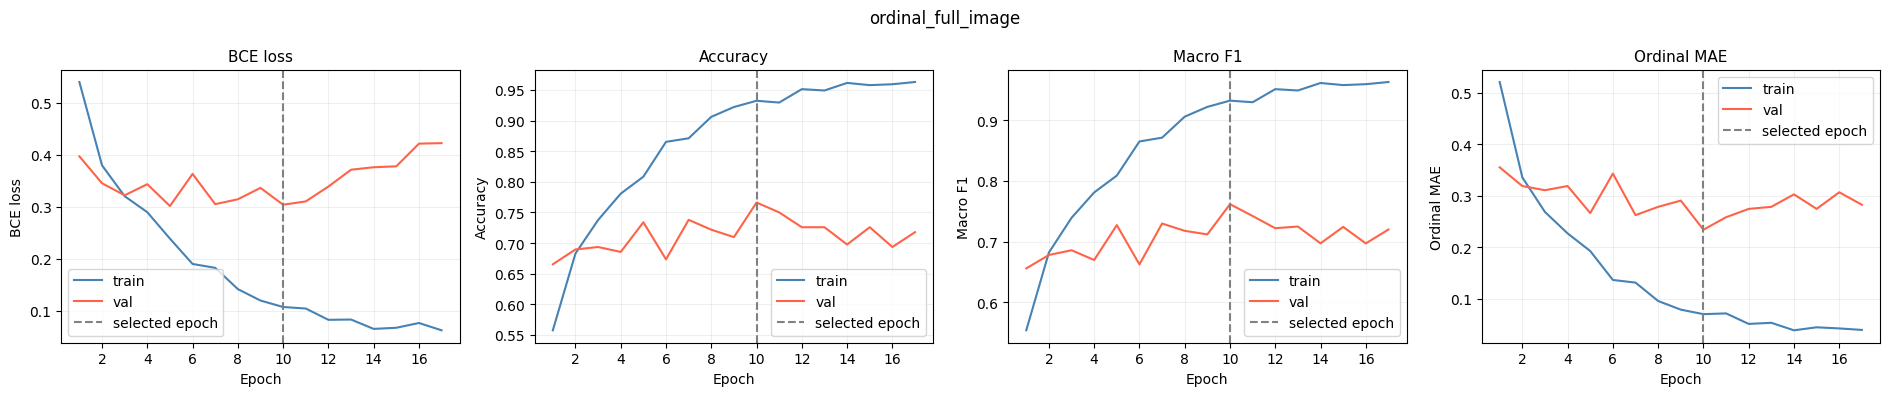

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/ordinal_full_image_history.png
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/logs/ordinal_full_image_overfitting_review.json
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/validation_metrics.csv


,configuration,learning_rate,augmentation,loss,best_epoch,val_accuracy,val_macro_f1,severe_recall,val_loss,val_ordinal_mae,val_catastrophic_error_rate,minor_f1,moderate_f1,severe_f1
0,ordinal_full_image,0.00003,strong,BCEWithLogitsLoss,10,0.766129,0.761706,0.769231,0.303921,0.233871,0.0,0.857143,0.623377,0.804598


Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/selected_model.json
Selected ordinal_full_image: val Macro F1=0.7617; epoch=10
No test predictions or test visualizations have been used for this decision.
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/validation_metrics.json
Validation ordinal consistency: {'inconsistent_count': 18, 'inconsistent_rate': 0.07258064516129033, 'mean_positive_order_gap': 5.869657616131008e-05}


In [9]:
validation_rows=[]
for result in [selected_result]:
    cfg=result['candidate'];val=result['validation'];history=pd.DataFrame(result['history'])
    validation_rows.append({'configuration':result['name'],'learning_rate':cfg['learning_rate'],
        'augmentation':cfg['augmentation'],'loss':cfg['loss'],'best_epoch':result['best_epoch'],
        'val_accuracy':val['accuracy'],'val_macro_f1':val['macro_f1'],'severe_recall':val['severe_recall'],
        'val_loss':val['loss'],'val_ordinal_mae':val['ordinal_mae'],'val_catastrophic_error_rate':val['catastrophic_error_rate'],**{f'{cls}_f1':val[f'{cls}_f1'] for cls in CLASSES}})
    fig,axes=plt.subplots(1,4,figsize=(19,4))
    for ax,key,title in zip(axes,['loss','accuracy','macro_f1','ordinal_mae'],['BCE loss','Accuracy','Macro F1','Ordinal MAE']):
        for split,color in [('train','steelblue'),('val','tomato')]:
            ax.plot(history.epoch,history[f'{split}_{key}'],label=split,color=color)
        ax.axvline(result['best_epoch'],color='gray',linestyle='--',label='selected epoch')
        ax.set(xlabel='Epoch',ylabel=title,title=title)
        ax.legend();ax.grid(alpha=0.2)
    fig.suptitle(result['name'])
    save_figure(fig,FIGURES_DIR / f'{result["name"]}_history.png')
    window=CONFIG['overfit_window']
    flag=False
    if len(history)>=2*window:
        prior=history.iloc[-2*window:-window];recent=history.iloc[-window:]
        flag=bool(recent.train_accuracy.mean()-prior.train_accuracy.mean()>=CONFIG['overfit_train_gain'] and
                  prior.val_macro_f1.mean()-recent.val_macro_f1.mean()>=CONFIG['overfit_val_drop'])
    save_json({'candidate':result['name'],'possible_overfitting':flag,
               'rule':'Sustained windowed train-accuracy gain and validation-F1 drop; review only.'},
              LOGS_DIR / f'{result["name"]}_overfitting_review.json')
    if flag:
        print(f'{result["name"]}: possible overfitting; review the curves and retained best epoch.')
validation_table=pd.DataFrame(validation_rows)
save_table(validation_table,TABLES_DIR / 'validation_metrics.csv')
display(validation_table.sort_values(['val_macro_f1','severe_recall','val_loss'],ascending=[False,False,True]))

selection={'name':selected_result['name'],'candidate':selected_result['candidate'],
           'checkpoint_path':selected_result['checkpoint_path'],'checkpoint_sha256':selected_result['checkpoint_sha256'],
           'best_epoch':selected_result['best_epoch'],'validation':selected_result['validation'],
           'study_signature':STUDY_SIGNATURE,'dataset_id':DATASET_ID,'candidate_count':1,
           'reason':'Highest validation Macro F1; exact ties use severe recall then lower unweighted validation loss.',
           'refit_policy':'No train+validation refit; retain the selected training checkpoint.'}
if SELECTION_PATH.exists():
    assert json.loads(SELECTION_PATH.read_text())==selection, 'Frozen selection cannot be changed.'
else:
    save_json(selection,SELECTION_PATH)
print(f'Selected {selection["name"]}: val Macro F1={selection["validation"]["macro_f1"]:.4f}; epoch={selection["best_epoch"]}')
print('No test predictions or test visualizations have been used for this decision.')
save_json(selection['validation'],RESULTS_DIR / 'validation_metrics.json')
print('Validation ordinal consistency:',{k:v for k,v in selection['validation'].items() if 'inconsistent' in k or 'order_gap' in k})

## 9. FINAL TEST - RUN ONCE ONLY

Reload exactly the frozen validation checkpoint. Checksummed batches resume an interrupted evaluation; a completed evaluation only reuses saved logits. Missing or damaged completed caches stop execution rather than silently retest.

In [10]:
assert json.loads(SELECTION_PATH.read_text())==selection
assert sha256_file(selection['checkpoint_path'])==selection['checkpoint_sha256'], 'Selected checkpoint changed'
TEST_SIGNATURE=fingerprint({'selection':selection,'dataset':DATASET_ID,'representation':'full_image',
                            'input_size':CONFIG['input_size'],'mean':CONFIG['mean'],'std':CONFIG['std']})
if TEST_LOCK_PATH.exists():
    test_lock=json.loads(TEST_LOCK_PATH.read_text())
    assert test_lock['signature']==TEST_SIGNATURE, 'A different configuration is already locked to this test set.'
else:
    test_lock={'signature':TEST_SIGNATURE,'status':'started','selected_model':selection['name']}
    save_json(test_lock,TEST_LOCK_PATH)
TEST_UNLOCKED=True
checkpoint=torch.load(selection['checkpoint_path'],map_location=DEVICE,weights_only=True)
assert checkpoint['class_to_idx']==CLASS_TO_IDX and checkpoint['dataset_id']==DATASET_ID
assert checkpoint['candidate']==selection['candidate']
model=build_resnet(pretrained=False)
model.load_state_dict(checkpoint['model_state'],strict=True)
model.eval().requires_grad_(False)
del checkpoint
print(f'Reloaded exactly the selected checkpoint: {selection["checkpoint_path"]}')

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/test_evaluation_lock.json
Reloaded exactly the selected checkpoint: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/checkpoints/best_ordinal_resnet50.pth


Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/final_test_metrics.json
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/classification_report.csv
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/test_predictions.csv
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/confusion_matrix.csv
              precision    recall  f1-score   support

       minor     0.7222    0.8966    0.8000        29
    moderate     0.8095    0.5000    0.6182        34
      severe     0.5333    0.8889    0.6667         9

    accuracy                         0.7083        72
   macro avg     0.6884    0.7618    0.6949        72
weighted avg     0.7398    0.7083    0.6975        72



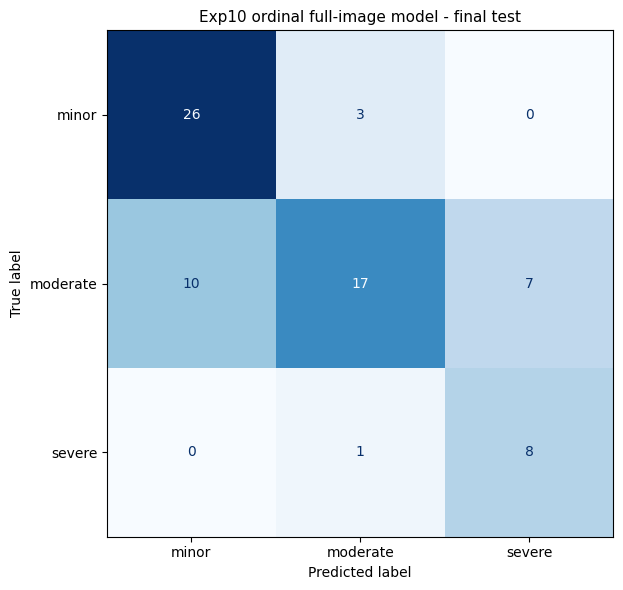

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/confusion_matrix.png
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/test_evaluation_lock.json
Final test complete. No candidate selection or tuning follows this cell.
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/ordinal_metrics.json
Ordinal test metrics: {'accuracy': 0.7083333333333334, 'macro_precision': 0.6883597883597883, 'macro_recall': 0.7618135376756067, 'macro_f1': 0.694949494949495, 'weighted_f1': 0.6974747474747475, 'minor_f1': 0.8, 'moderate_f1': 0.6181818181818182, 'severe_f1': 0.6666666666666666, 'severe_recall': 0.8888888888888888, 'minor_to_moderate': 3, 'minor_to_severe': 0, 'moderate_to_minor': 10, 'moderate_to_severe': 7, 'severe_to_minor': 0, 'severe_to_moderate': 1, 'ordinal_mae': 0.2916666666666667, 'off_by_one_rate': 0.2916666666666667, 'catastrophic_error_rate': 0.0, 'quadratic_weighted_kappa': 0.7284482

In [11]:
def validate_batch(output,rows):
    assert np.array_equal(output['image_ids'],np.array([r['image_id'] for r in rows])), 'Test batch IDs differ'
    assert np.array_equal(output['labels'],np.array([r['label'] for r in rows])), 'Test batch labels differ'
    assert output['logits'].shape==(len(rows),CONFIG['ordinal_outputs']) and np.isfinite(output['logits']).all(), 'Invalid test logits'
    return output

def final_test_once(model,rows):
    """One frozen evaluation; batch journals retain work across runtime interruption."""
    require_test_unlocked()
    directory=CACHE_DIR / 'final_test' / TEST_SIGNATURE
    directory.mkdir(parents=True,exist_ok=True)
    collected=[]
    for start in range(0,len(rows),CONFIG['batch_size']):
        batch=rows[start:start+CONFIG['batch_size']]
        path=directory / f'batch_{start:06d}.npz';meta_path=path.with_suffix('.json')
        batch_signature=fingerprint({'test':TEST_SIGNATURE,'rows':[
            {k:r[k] for k in ['image_id','label','original_sha256']} for r in batch]})
        output=None
        if path.exists() and meta_path.exists():
            try:
                meta=json.loads(meta_path.read_text())
                assert meta['signature']==batch_signature and meta['sha256']==sha256_file(path)
                with np.load(path,allow_pickle=False) as stored:
                    output=validate_batch({key:stored[key].copy() for key in stored.files},batch)
            except (OSError,ValueError,KeyError,AssertionError,zipfile.BadZipFile) as error:
                if test_lock['status']=='completed':
                    raise RuntimeError('Completed test cache is damaged; restore it instead of evaluating again.') from error
                print(f'Incomplete test batch rejected: {start}: {error}')
                output=None
        if output is None:
            if test_lock['status']=='completed':
                raise RuntimeError('Completed test cache is missing. Restore the saved cache; automatic retesting is blocked.')
            images=torch.stack([EVAL_TF(read_rgb(r['original_path'])) for r in batch])
            with torch.inference_mode():
                logits=model(images.to(DEVICE)).cpu().numpy()
            output=validate_batch({'image_ids':np.array([r['image_id'] for r in batch]),
                                   'labels':np.array([r['label'] for r in batch]),'logits':logits},batch)
            temporary=path.with_suffix('.tmp.npz')
            np.savez_compressed(temporary,**output);temporary.replace(path)
            save_json({'signature':batch_signature,'sha256':sha256_file(path)},meta_path,announce=False)
        collected.append(output)
    output={key:np.concatenate([batch[key] for batch in collected]) for key in collected[0]}
    return validate_batch(output,rows)

test_output=final_test_once(model,records['test'])
pred_tensor,prob_tensor=decode_ordinal(torch.as_tensor(test_output['logits'],dtype=torch.float64))
probabilities=prob_tensor.numpy()
test_predictions=pd.DataFrame({'image_id':test_output['image_ids'],'label':test_output['labels'],
    'prediction':pred_tensor.numpy(),'p_gt_minor':probabilities[:,0],'p_gt_moderate':probabilities[:,1]})
test_predictions['true_class']=test_predictions.label.map(dict(enumerate(CLASSES)))
test_predictions['predicted_class']=test_predictions.prediction.map(dict(enumerate(CLASSES)))
test_predictions['correct']=test_predictions.label==test_predictions.prediction
test_predictions['ordinal_distance']=abs(test_predictions.label-test_predictions.prediction)
test_predictions['inconsistent']=probabilities[:,1]>probabilities[:,0]
test_predictions=test_predictions.merge(pd.DataFrame(records['test'])[['image_id','original_path']],
                                        on='image_id',validate='one_to_one')
final_metrics,report,cm=metric_bundle(test_predictions.label,test_predictions.prediction)
final_metrics.update(consistency_metrics(probabilities))
save_json(final_metrics,RESULTS_DIR / 'final_test_metrics.json')
save_table(pd.DataFrame(report).T,TABLES_DIR / 'classification_report.csv',index=True)
save_table(test_predictions,TABLES_DIR / 'test_predictions.csv')
save_table(pd.DataFrame(cm,index=CLASSES,columns=CLASSES),TABLES_DIR / 'confusion_matrix.csv',index=True)
report_text=classification_report(test_predictions.label,test_predictions.prediction,labels=list(range(len(CLASSES))),
                                 target_names=CLASSES,digits=4,zero_division=0)
(RESULTS_DIR / 'classification_report.txt').write_text(report_text,encoding='utf-8')
print(report_text)
fig,ax=plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm,display_labels=CLASSES).plot(ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Exp10 ordinal full-image model - final test')
save_figure(fig,FIGURES_DIR / 'confusion_matrix.png')
np.savez_compressed(RESULTS_DIR / 'final_test_outputs.npz',**test_output,threshold_probabilities=probabilities)
test_lock.update(status='completed',samples=len(test_predictions))
save_json(test_lock,TEST_LOCK_PATH)
TEST_EVALUATED=True
print('Final test complete. No candidate selection or tuning follows this cell.')
save_json({k:final_metrics[k] for k in ['ordinal_mae','off_by_one_rate','catastrophic_error_rate','quadratic_weighted_kappa','inconsistent_count','inconsistent_rate','mean_positive_order_gap','invalid_threshold_pattern_count']},RESULTS_DIR / 'ordinal_metrics.json')
print('Ordinal test metrics:',final_metrics)
if final_metrics['inconsistent_rate']>=CONFIG['consistency_warning_rate']:
    print('Frequent p2 > p1 outputs: review this limitation. No post-test correction or threshold tuning is applied.')

## 10. Exp09 vs Exp10 Comparison

Open saved Exp09 test predictions only after our final test. Verify the frozen model, dataset, and sample identities. Derive ordinal distances for both methods from the same labels; no model is evaluated again on test.

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/paired_exp09_vs_exp10.csv
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/exp09_vs_exp10_comparison.csv


,Metric,Exp09 Standard Full Image,Exp10 Ordinal Full Image,Difference,Direction,Outcome
0,Validation Macro F1,0.765472,0.761706,-0.003766,higher is better,worsened
1,Test accuracy,0.638889,0.708333,0.069444,higher is better,improved
2,Test macro_f1,0.605655,0.694949,0.089295,higher is better,improved
3,minor recall,0.862069,0.896552,0.034483,higher is better,improved
4,minor f1-score,0.781250,0.800000,0.018750,higher is better,improved
5,moderate recall,0.441176,0.500000,0.058824,higher is better,improved
6,moderate f1-score,0.535714,0.618182,0.082468,higher is better,improved
7,severe recall,0.666667,0.888889,0.222222,higher is better,improved
8,severe f1-score,0.500000,0.666667,0.166667,higher is better,improved
9,minor_to_moderate,4.000000,3.000000,-1.000000,lower is better,improved


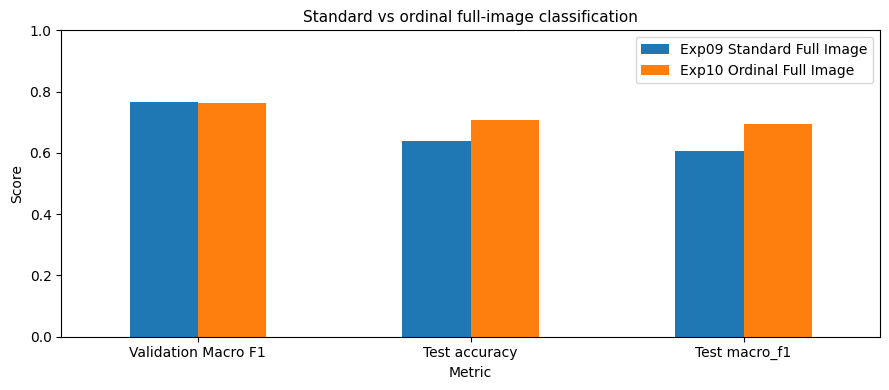

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/exp09_vs_exp10.png


In [12]:
assert TEST_EVALUATED
base_lock=read_json(EXP09_DIR / 'results/test_evaluation_lock.json')
expected_base_signature=fingerprint({'selection':BASE_SELECTION,'dataset':DATASET_ID,'representation':'full_image',
    'input_size':BASE_CONFIG['input_size'],'mean':BASE_CONFIG['mean'],'std':BASE_CONFIG['std']})
assert base_lock['status']=='completed' and base_lock['signature']==expected_base_signature
assert base_lock['selected_model']==BASE_SELECTION['name']
base_predictions=pd.read_csv(EXP09_DIR / 'tables/test_predictions.csv')
assert not base_predictions.image_id.duplicated().any()
assert set(base_predictions.image_id)==set(test_predictions.image_id)
with np.load(EXP09_DIR / 'results/final_test_outputs.npz',allow_pickle=False) as stored:
    base_arrays={key:stored[key].copy() for key in stored.files}
assert np.array_equal(base_arrays['image_ids'],base_predictions.image_id)
assert np.array_equal(base_arrays['labels'],base_predictions.label)
assert base_arrays['logits'].shape==(len(base_predictions),len(CLASSES))
assert np.isfinite(base_arrays['logits']).all()
base_prob=torch.as_tensor(base_arrays['logits'],dtype=torch.float64).softmax(1).numpy()
assert np.allclose(base_prob,base_arrays['probabilities'])
assert np.array_equal(base_prob.argmax(1),base_predictions.prediction)
assert np.allclose(base_prob.max(1),base_predictions.confidence)
base_metrics,base_report,base_cm=metric_bundle(base_predictions.label,base_predictions.prediction)
saved_metrics=read_json(EXP09_DIR / 'results/final_test_metrics.json')
for key,value in saved_metrics.items():
    if key in base_metrics:
        assert value==base_metrics[key] if value is None else np.isclose(value,base_metrics[key]), key
paired=test_predictions[['image_id','original_path','label','prediction','p_gt_minor','p_gt_moderate']].merge(
    base_predictions[['image_id','label','prediction','confidence']],on='image_id',suffixes=('_exp10','_exp09'),validate='one_to_one')
assert np.array_equal(paired.label_exp10,paired.label_exp09)
paired['true_class']=paired.label_exp10.map(dict(enumerate(CLASSES)))
for exp in ['exp09','exp10']:
    paired[exp+'_class']=paired['prediction_'+exp].map(dict(enumerate(CLASSES)))
    paired[exp+'_distance']=abs(paired['prediction_'+exp]-paired.label_exp10)
    paired[exp+'_correct']=paired[exp+'_distance']==0
save_table(paired,TABLES_DIR / 'paired_exp09_vs_exp10.csv')
comparison_rows=[]
def add_comparison(metric,standard,ordinal,lower_is_better=False):
    delta=ordinal-standard
    comparison_rows.append({'Metric':metric,'Exp09 Standard Full Image':standard,
        'Exp10 Ordinal Full Image':ordinal,'Difference':delta,
        'Direction':'lower is better' if lower_is_better else 'higher is better',
        'Outcome':'unchanged' if delta==0 else ('improved' if (delta<0 if lower_is_better else delta>0) else 'worsened')})
add_comparison('Validation Macro F1',BASE_SELECTION['validation']['macro_f1'],selection['validation']['macro_f1'])
for key in ['accuracy','macro_f1']:
    add_comparison('Test '+key,base_metrics[key],final_metrics[key])
for cls in CLASSES:
    for key in ['recall','f1-score']:
        add_comparison(cls+' '+key,base_report[cls][key],report[cls][key])
for source in CLASSES:
    for target in CLASSES:
        if source!=target:
            key=source+'_to_'+target
            add_comparison(key,base_metrics[key],final_metrics[key],True)
for key in ['ordinal_mae','off_by_one_rate','catastrophic_error_rate']:
    add_comparison(key,base_metrics[key],final_metrics[key],True)
if base_metrics['quadratic_weighted_kappa'] is not None and final_metrics['quadratic_weighted_kappa'] is not None:
    add_comparison('quadratic_weighted_kappa',base_metrics['quadratic_weighted_kappa'],final_metrics['quadratic_weighted_kappa'])
comparison=pd.DataFrame(comparison_rows)
save_table(comparison,TABLES_DIR / 'exp09_vs_exp10_comparison.csv')
display(comparison)
fig,ax=plt.subplots(figsize=(9,4))
comparison.iloc[:3].set_index('Metric')[['Exp09 Standard Full Image','Exp10 Ordinal Full Image']].plot.bar(ax=ax,rot=0)
ax.set(title='Standard vs ordinal full-image classification',ylabel='Score',ylim=(0,1))
save_figure(fig,FIGURES_DIR / 'exp09_vs_exp10.png')

## 11. Paired Errors and Moderate Cases

Count both exact corrections and changes in ordinal distance. Galleries use deterministic sample-ID order. Moderate examples are examined only after final testing.

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/paired_error_summary.csv


,group,samples,both_correct,both_wrong,exp09_correct_exp10_wrong,exp09_wrong_exp10_correct,ordinal_error_improved,ordinal_error_worsened,catastrophic_errors_fixed,catastrophic_errors_introduced
0,all,72,43,18,3,8,8,3,0,0
1,minor,29,24,2,1,2,2,1,0,0
2,moderate,34,13,15,2,4,4,2,0,0
3,severe,9,6,1,0,2,2,0,0,0


Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/moderate_analysis.csv


,model,samples,moderate_recall,moderate_to_minor,moderate_to_severe
0,exp09,34,0.441176,10,9
1,exp10,34,0.500000,10,7


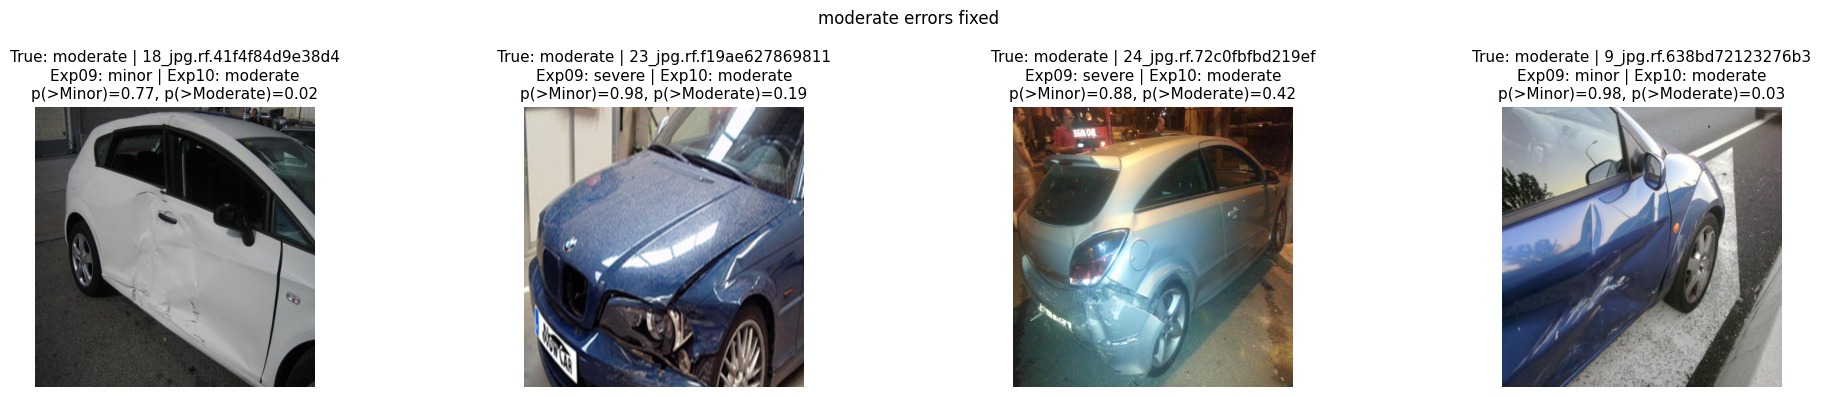

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/moderate_errors_fixed.png


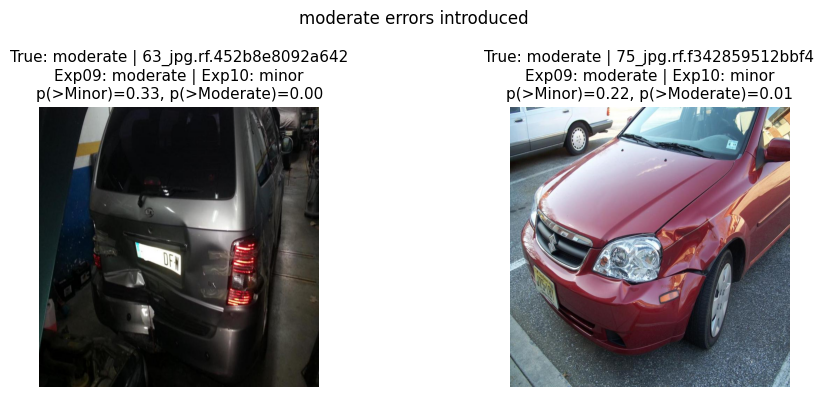

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/moderate_errors_introduced.png


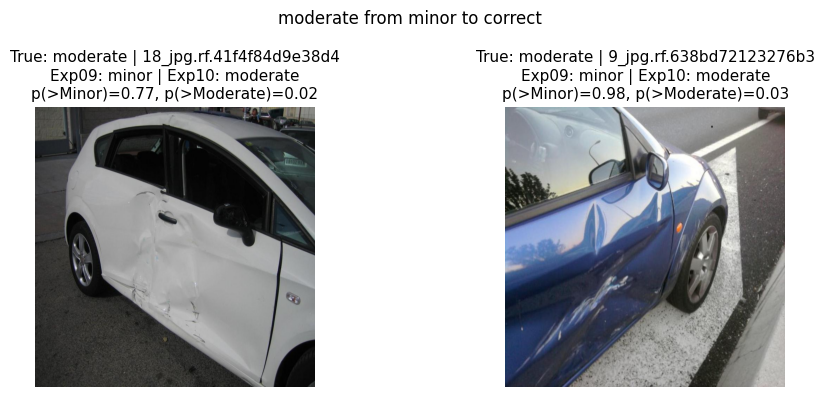

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/moderate_from_minor_to_correct.png


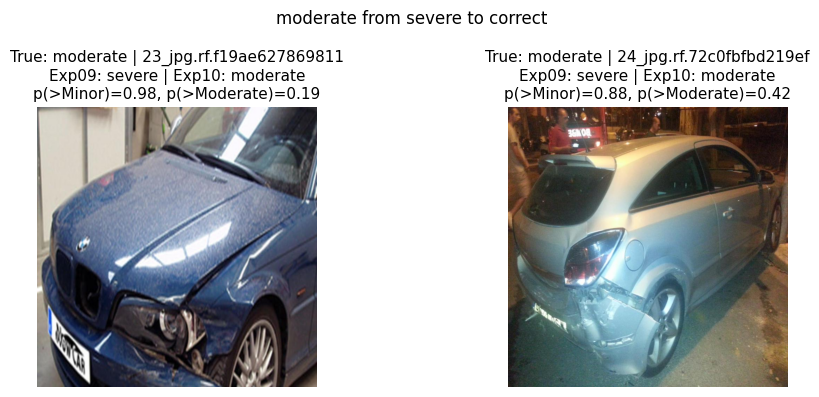

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/figures/moderate_from_severe_to_correct.png


In [13]:
def paired_counts(frame):
    old,new=frame.exp09_distance,frame.exp10_distance
    return {'samples':len(frame),'both_correct':int(((old==0)&(new==0)).sum()),
        'both_wrong':int(((old>0)&(new>0)).sum()),
        'exp09_correct_exp10_wrong':int(((old==0)&(new>0)).sum()),
        'exp09_wrong_exp10_correct':int(((old>0)&(new==0)).sum()),
        'ordinal_error_improved':int((new<old).sum()),'ordinal_error_worsened':int((new>old).sum()),
        'catastrophic_errors_fixed':int(((old==2)&(new<2)).sum()),
        'catastrophic_errors_introduced':int(((old<2)&(new==2)).sum())}
paired_summary=pd.DataFrame([{'group':'all',**paired_counts(paired)}]+[
    {'group':cls,**paired_counts(paired[paired.true_class==cls])} for cls in CLASSES])
save_table(paired_summary,TABLES_DIR / 'paired_error_summary.csv')
display(paired_summary)
def gallery(frame,name):
    selected=frame.sort_values('image_id').head(CONFIG['gallery_samples'])
    if selected.empty:
        print(name+': no matching samples');return
    fig,axes=plt.subplots(1,len(selected),figsize=(5*len(selected),4),squeeze=False)
    for ax,(_,row) in zip(axes.flat,selected.iterrows()):
        ax.imshow(read_rgb(row.original_path));ax.axis('off')
        ax.set_title(f"True: {row.true_class} | {Path(row.image_id).name[:24]}\nExp09: {row.exp09_class} | Exp10: {row.exp10_class}\np(>Minor)={row.p_gt_minor:.2f}, p(>Moderate)={row.p_gt_moderate:.2f}")
    fig.suptitle(name.replace('_',' '));save_figure(fig,FIGURES_DIR / (name+'.png'))
moderate=paired[paired.true_class=='moderate']
moderate_rows=[]
for exp in ['exp09','exp10']:
    pred=moderate['prediction_'+exp]
    moderate_rows.append({'model':exp,'samples':len(moderate),
        'moderate_recall':float((pred==CLASS_TO_IDX['moderate']).mean()) if len(moderate) else None,
        'moderate_to_minor':int((pred==CLASS_TO_IDX['minor']).sum()),
        'moderate_to_severe':int((pred==CLASS_TO_IDX['severe']).sum())})
save_table(pd.DataFrame(moderate_rows),TABLES_DIR / 'moderate_analysis.csv')
display(pd.DataFrame(moderate_rows))
gallery(moderate[~moderate.exp09_correct & moderate.exp10_correct],'moderate_errors_fixed')
gallery(moderate[moderate.exp09_correct & ~moderate.exp10_correct],'moderate_errors_introduced')
for old_class in ['minor','severe']:
    gallery(moderate[(moderate.exp09_class==old_class)&moderate.exp10_correct],'moderate_from_'+old_class+'_to_correct')

## 12. Catastrophic Errors and Ordinal Consistency

A two-level error jumps between Minor and Severe. Report each direction separately. An inconsistency is p(>Moderate) > p(>Minor); its rate measures a limitation of this simple independent-head model, not a classification error by itself.

In [14]:
catastrophic=[]
for true,pred in [('minor','severe'),('severe','minor')]:
    for exp in ['exp09','exp10']:
        mask=(paired.true_class==true)&(paired[exp+'_class']==pred)
        catastrophic.append({'model':exp,'transition':true+' -> '+pred,'count':int(mask.sum())})
        gallery(paired[mask],exp+'_'+true+'_to_'+pred)
save_table(pd.DataFrame(catastrophic),TABLES_DIR / 'catastrophic_errors.csv')
display(pd.DataFrame(catastrophic))
gallery(paired[(paired.exp09_distance==2)&(paired.exp10_distance<2)],'catastrophic_errors_fixed')
gallery(paired[(paired.exp09_distance<2)&(paired.exp10_distance==2)],'catastrophic_errors_introduced')
consistency=pd.DataFrame([{'split':split,**{key:metrics[key] for key in ['inconsistent_count','inconsistent_rate','mean_positive_order_gap','invalid_threshold_pattern_count']}}
    for split,metrics in [('validation_selected',selection['validation']),('test',final_metrics)]])
save_table(consistency,TABLES_DIR / 'ordinal_consistency.csv')
display(consistency)

exp09_minor_to_severe: no matching samples
exp10_minor_to_severe: no matching samples
exp09_severe_to_minor: no matching samples
exp10_severe_to_minor: no matching samples
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/catastrophic_errors.csv


,model,transition,count
0,exp09,minor -> severe,0
1,exp10,minor -> severe,0
2,exp09,severe -> minor,0
3,exp10,severe -> minor,0


catastrophic_errors_fixed: no matching samples
catastrophic_errors_introduced: no matching samples
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/tables/ordinal_consistency.csv


,split,inconsistent_count,inconsistent_rate,mean_positive_order_gap,invalid_threshold_pattern_count
0,validation_selected,18,0.072581,0.000059,0
1,test,3,0.041667,0.000257,0


## 13. Optional Unlabeled Domain Images

Run both full-image classifiers on each available domain image, including the hood case if present. Cache logits using source and model hashes. Exp10 displays two threshold probabilities, never softmax-style class probabilities. No domain accuracy is calculated.

For an arbitrary hood filename, set `white_hood_image_path` in the initial configuration. Every supported domain image is processed regardless of its filename.

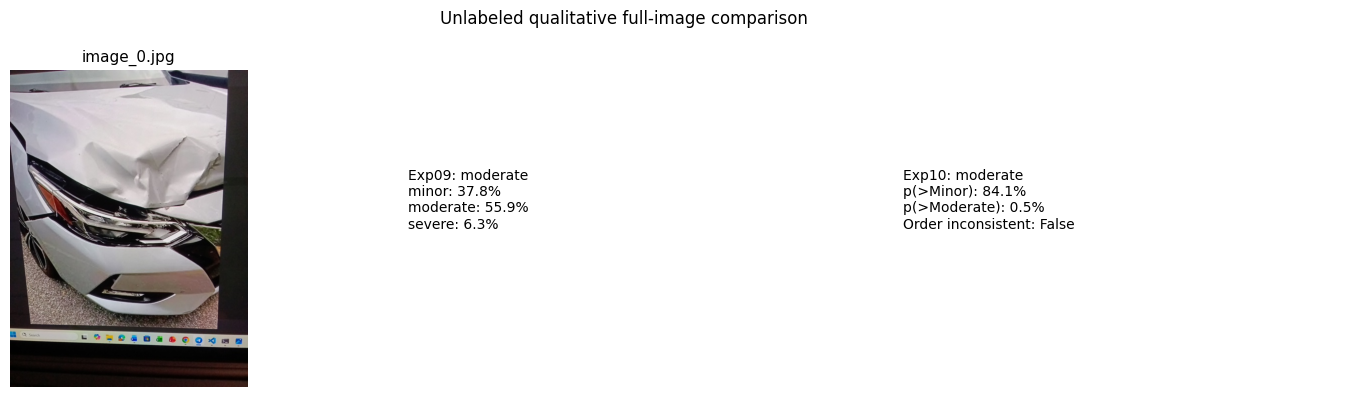

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/domain_test/6b7fb1ad64bad0302603872f62578426ad6551cbaaf96fcdc3557bec42f387b4.png
Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/domain_test/domain_predictions.csv


,image_path,exp09_prediction,exp10_prediction,p_gt_minor,p_gt_moderate,inconsistent,exp09_probability_minor,exp09_probability_moderate,exp09_probability_severe,white_hood_case
0,/content/drive/MyDrive/Severity_Model/domain_t...,moderate,moderate,0.840626,0.004727,False,0.377554,0.559014,0.063433,False


All images processed. Hood identity was not established; set white_hood_image_path for a named case study.


In [15]:
domain_folder=Path(CONFIG['domain_image_path'])
domain_paths=sorted(p for p in domain_folder.rglob('*') if p.is_file() and p.suffix.lower() in CONFIG['supported_extensions']) if domain_folder.is_dir() else []
standard_model=None
def domain_logits(path,kind):
    global standard_model
    checkpoint_hash=BASE_SELECTION['checkpoint_sha256'] if kind=='exp09' else selection['checkpoint_sha256']
    signature=fingerprint({'image_sha256':sha256_file(path),'checkpoint':checkpoint_hash,
        'size':CONFIG['input_size'],'mean':CONFIG['mean'],'std':CONFIG['std'],'versions':VERSIONS,'kind':kind})
    cache=DOMAIN_TEST_DIR / (signature+'.json')
    if cache.exists():
        entry=read_json(cache);assert entry['signature']==signature
        logits=torch.tensor(entry['logits'],dtype=torch.float64)
    else:
        if kind=='exp09' and standard_model is None:
            assert sha256_file(BASE_SELECTION['checkpoint_path'])==BASE_SELECTION['checkpoint_sha256']
            state=torch.load(BASE_SELECTION['checkpoint_path'],map_location=DEVICE,weights_only=True)
            assert state['config']==BASE_CONFIG and state['class_to_idx']==CLASS_TO_IDX
            assert state['dataset_id']==DATASET_ID
            standard_model=models.resnet50(weights=None)
            standard_model.fc=nn.Linear(standard_model.fc.in_features,len(CLASSES))
            standard_model.load_state_dict(state['model_state'],strict=True)
            standard_model=standard_model.to(DEVICE).eval().requires_grad_(False)
            del state
        current=standard_model if kind=='exp09' else model
        with torch.inference_mode():
            logits=current(EVAL_TF(read_rgb(path)).unsqueeze(0).to(DEVICE)).double().cpu()
        save_json({'signature':signature,'logits':logits.tolist()},cache,announce=False)
    assert logits.shape==(1,3 if kind=='exp09' else CONFIG['ordinal_outputs']) and torch.isfinite(logits).all()
    return logits

domain_rows=[]
if not domain_paths: print('No optional domain images; qualitative comparison skipped.')
for path in domain_paths:
    standard_prob=domain_logits(path,'exp09').softmax(1)[0].numpy()
    prediction,thresholds=decode_ordinal(domain_logits(path,'exp10'))
    probs=thresholds[0].numpy()
    row={'image_path':str(path),'exp09_prediction':CLASSES[int(standard_prob.argmax())],
         'exp10_prediction':CLASSES[int(prediction.item())],'p_gt_minor':float(probs[0]),
         'p_gt_moderate':float(probs[1]),'inconsistent':bool(probs[1]>probs[0]),
         **{'exp09_probability_'+cls:float(standard_prob[i]) for i,cls in enumerate(CLASSES)}}
    row['white_hood_case']=(CONFIG.get('white_hood_image_path') is not None and path==Path(CONFIG['white_hood_image_path'])) or ('white' in path.stem.lower() and 'hood' in path.stem.lower())
    domain_rows.append(row)
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    axes[0].imshow(read_rgb(path));axes[0].set_title(path.name)
    axes[1].text(.05,.5,'Exp09: '+row['exp09_prediction']+'\n'+'\n'.join(f'{cls}: {standard_prob[i]:.1%}' for i,cls in enumerate(CLASSES)))
    axes[2].text(.05,.5,f"Exp10: {row['exp10_prediction']}\np(>Minor): {probs[0]:.1%}\np(>Moderate): {probs[1]:.1%}\nOrder inconsistent: {row['inconsistent']}")
    for ax in axes:ax.axis('off')
    fig.suptitle('Unlabeled qualitative full-image comparison')
    save_figure(fig,DOMAIN_TEST_DIR / (fingerprint(str(path))+'.png'))
    if row['white_hood_case']:
        print('Qualitative case study based on visually substantial hood deformation; no formal ground truth.')
        save_json(row,DOMAIN_TEST_DIR / 'white_hood_case_study.json')
if domain_rows:
    save_table(pd.DataFrame(domain_rows),DOMAIN_TEST_DIR / 'domain_predictions.csv')
    display(pd.DataFrame(domain_rows))
    if not any(row['white_hood_case'] for row in domain_rows):
        print('All images processed. Hood identity was not established; set white_hood_image_path for a named case study.')
if standard_model is not None:
    del standard_model
    standard_model=None

## 14. Evidence-Based Summary

Review classification quality and ordinal error size together. A reduction in large errors can matter even with lower F1, but that tradeoff must be explicit. One fixed test split and unlabeled domain examples cannot establish production readiness.

In [16]:
f1_change=final_metrics['macro_f1']-base_metrics['macro_f1']
mae_change=final_metrics['ordinal_mae']-base_metrics['ordinal_mae']
cat_change=final_metrics['catastrophic_error_rate']-base_metrics['catastrophic_error_rate']
moderate_change=report['moderate']['recall']-base_report['moderate']['recall']
if f1_change>=0 and mae_change<=0 and cat_change<=0 and moderate_change>=0 and any([f1_change>0,mae_change<0,cat_change<0,moderate_change>0]):
    conclusion='Ordinal learning shows a useful benchmark improvement without worsening the main monitored measures. Confirm this on labeled domain data before replacing standard classification.'
elif f1_change<0 and mae_change>0 and cat_change>=0:
    conclusion='Ordinal learning worsened classification and ordinal error size in this run. It does not support replacing the standard classifier.'
elif f1_change<0 and cat_change<0:
    conclusion='Ordinal learning reduced catastrophic errors but lowered Macro F1. This is a tradeoff, not an automatic win; review Moderate recall and individual transitions.'
else:
    conclusion='The evidence is mixed or unchanged. Compare class recalls, ordinal distances, and paired corrections before choosing an approach.'
summary={'model':{'best_epoch':selection['best_epoch'],'validation':selection['validation']},
    'final_test':final_metrics,'exp09_test':base_metrics,'comparison':comparison.to_dict('records'),
    'paired_analysis':paired_counts(paired),'domain_cases':domain_rows,
    'large_ordinal_mistakes_decreased':bool(cat_change<0),'conclusion':conclusion,
    'replacement_decision':'No automatic replacement; review benchmark tradeoffs and obtain labeled domain evidence.',
    'next_experiment':'A follow-up is justified only by remaining class errors or frequent order inconsistencies; no further tuning is performed here.',
    'limitations':'One seed and fixed test split; threshold probabilities are uncalibrated; independent logits need not be ordered.'}
save_json(summary,RESULTS_DIR / 'exp10_summary.json')
text_summary=conclusion+'\n\nBest epoch: '+str(selection['best_epoch'])+'\nValidation Macro F1: '+str(selection['validation']['macro_f1'])+'\nValidation ordinal MAE: '+str(selection['validation']['ordinal_mae'])+'\n\n'+comparison.to_string(index=False)+'\n\n'+paired_summary.to_string(index=False)+'\n\nDomain cases (unlabeled):\n'+pd.DataFrame(domain_rows).to_string(index=False)+'\n\n'+summary['replacement_decision']+'\n'+summary['next_experiment']
(RESULTS_DIR / 'exp10_summary.txt').write_text(text_summary,encoding='utf-8')
print(text_summary)
print('Persisted ordinal experiment:',EXP_DIR)

Saved: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/results/exp10_summary.json
Ordinal learning shows a useful benchmark improvement without worsening the main monitored measures. Confirm this on labeled domain data before replacing standard classification.

Best epoch: 10
Validation Macro F1: 0.7617057272229686
Validation ordinal MAE: 0.23387096774193547

                  Metric  Exp09 Standard Full Image  Exp10 Ordinal Full Image  Difference        Direction   Outcome
     Validation Macro F1                   0.765472                  0.761706   -0.003766 higher is better  worsened
           Test accuracy                   0.638889                  0.708333    0.069444 higher is better  improved
           Test macro_f1                   0.605655                  0.694949    0.089295 higher is better  improved
            minor recall                   0.862069                  0.896552    0.034483 higher is better  improved
          minor f1-score       

### Decision Guide

| Question | Evidence |
|---|---|
| Did classification improve? | Macro F1 and each class recall/F1 |
| Did error size decrease? | MAE, two-level errors, and weighted kappa |
| Did Moderate improve? | Under/overestimation counts and paired cases |
| Are threshold outputs ordered? | p2 > p1 rate and gap |
| Should this replace Exp09? | Review all tradeoffs and labeled domain evidence first |

The 0.5 rule stays fixed. No post-test threshold adjustment, probability sorting, or new training follows these analyses.

In [17]:
model_save_path = EXP_DIR / 'severity_resnet50_ordinal_csp650_v1.pth'
torch.save(model.state_dict(), model_save_path)
print(f'Model weights saved to: {model_save_path}')

Model weights saved to: /content/drive/MyDrive/Severity_Model/exp10_csp650_ordinal_full_image/severity_resnet50_ordinal_csp650_v1.pth
